## Import modules

In [17]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

## ODE: $\frac{du}{dx}+u=0$, $u(0)=1$

Define ODE:

In [18]:
def ODE(u, x):
    du_dx = torch.autograd.grad(
        outputs = u,
        inputs = x,
        grad_outputs = torch.ones_like(u),
        create_graph = True
    )[0]

    return du_dx + u 

Define model:

In [19]:
torch.manual_seed(42)

model = nn.Sequential(
    nn.Linear(1, 20),
    nn.Tanh(),
    nn.Linear(20, 20),
    nn.Tanh(),
    nn.Linear(20, 20),
    nn.Tanh(),
    nn.Linear(20, 20),
    nn.Tanh(),
    nn.Linear(20, 20),
    nn.Tanh(),
    nn.Linear(20, 20),
    nn.Tanh(),
    nn.Linear(20, 20),
    nn.Tanh(),
    nn.Linear(20, 20),
    nn.Tanh(),
    nn.Linear(20, 1)
)

Define collocation points and boundary conditions:

In [20]:
collocation_points = np.linspace(0, 10, 101)
collocation_points = torch.tensor(collocation_points, dtype=torch.float)
collocation_points.requires_grad_(True)
x_boundary = torch.tensor([[0.0]], dtype=torch.float)
u_boundary = torch.tensor([[1.0]], dtype=torch.float)

Define loss function:

In [21]:
def loss_fcn(model, collocation_points, x_boundary, u_boundary):
    model.train()
    collocation_points = collocation_points.view(collocation_points.size(0), -1)
    u = model(collocation_points)

    residual = ODE(u, collocation_points)
    physics_loss = torch.mean(residual**2)

    u_boundary_pred = model(x_boundary)
    loss_function = nn.MSELoss()

    boundary_loss = loss_function(u_boundary_pred, u_boundary)

    total_loss = physics_loss + boundary_loss
    
    return physics_loss, boundary_loss, total_loss

Set up training cycle

In [22]:
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

physics_loss_list = []
boundary_loss_list = []
total_loss_list = []

Training model

In [23]:
start_epoch = 0
n_epochs = 1000
patience = 50

best_epoch = start_epoch

for i in range(start_epoch, start_epoch+n_epochs):
    physics_loss, boundary_loss, total_loss = loss_fcn(model, collocation_points, x_boundary, u_boundary)
    optimizer.zero_grad()
    total_loss.backward()
    optimizer.step()

    physics_loss_list.append(physics_loss.item())
    boundary_loss_list.append(boundary_loss.item())
    total_loss_list.append(total_loss.item())

    if i % 100 == 0:
        print(f'epoch:', i)

    if total_loss < total_loss_list[best_epoch]:
        best_epoch = i
    elif best_epoch <= i - patience:
        break

epoch: 0
epoch: 100
epoch: 200
epoch: 300
epoch: 400
epoch: 500
epoch: 600
epoch: 700
epoch: 800
epoch: 900


Plot losses

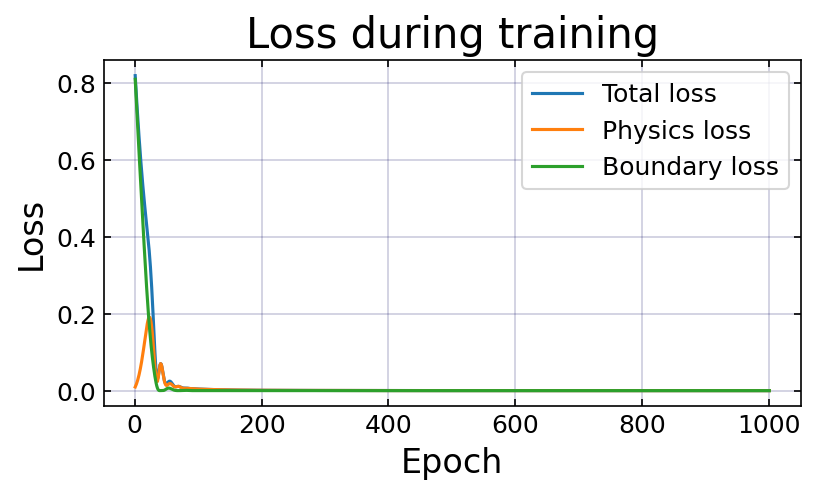

In [24]:
epochs = np.linspace(1, len(total_loss_list), len(total_loss_list))

fig, ax = plt.subplots(1,1,figsize = (6,3),dpi = 150)
ax.plot(epochs, total_loss_list, label='Total loss')
ax.plot(epochs, physics_loss_list, label='Physics loss')
ax.plot(epochs, boundary_loss_list, label='Boundary loss')
ax.set_xlabel('Epoch',fontsize = 16)
ax.set_ylabel('Loss',fontsize = 16) # Change loss function
ax.set_title('Loss during training',fontsize = 20)
ax.tick_params(labelsize=12, which='both',top=True, right = True, direction='in')
ax.grid(color='xkcd:dark blue',alpha = 0.2)
ax.legend(loc='upper right',fontsize = 12)
plt.show()


Compare with exact solution

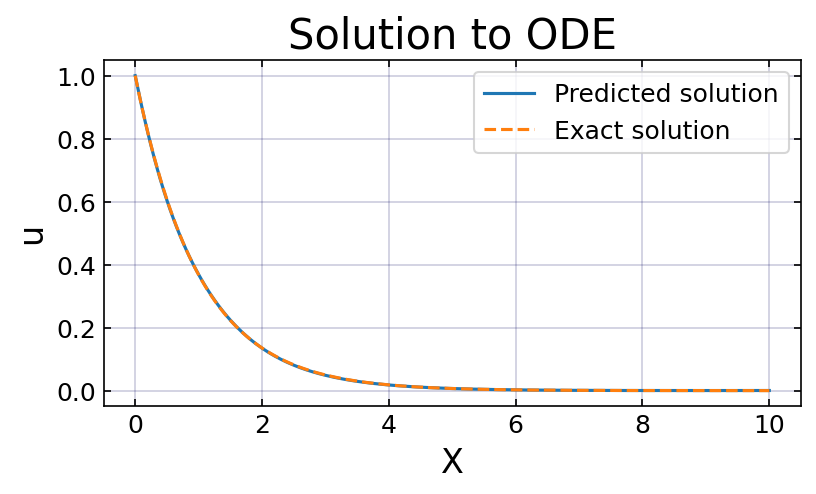

In [25]:
X_test = np.linspace(0, 10, 201)

model.eval()
with torch.no_grad():
    u_pred = model(torch.tensor(X_test, dtype=torch.float).view(len(X_test), -1))

u_exact = np.exp(-X_test)

fig, ax = plt.subplots(1,1,figsize = (6,3),dpi = 150)
ax.plot(X_test, u_pred, label='Predicted solution')
ax.plot(X_test, u_exact, label='Exact solution', linestyle='--')
ax.set_xlabel('X',fontsize = 16)
ax.set_ylabel('u',fontsize = 16)
ax.set_title('Solution to ODE',fontsize = 20)
ax.tick_params(labelsize=12, which='both',top=True, right = True, direction='in')
ax.grid(color='xkcd:dark blue',alpha = 0.2)
ax.legend(loc='upper right',fontsize = 12)
plt.show()
